In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

np.random.seed(42)
monthly_revenue = np.round(np.random.uniform(5000, 20000, size=len(months))).astype(int)

df = pd.DataFrame({
    "month": months,
    "revenue": monthly_revenue
})
df["cumulative"] = df["revenue"].cumsum()
df

,month,revenue,cumulative
0,Jan,10618,10618
1,Feb,19261,29879
2,Mar,15980,45859
3,Apr,13980,59839
4,May,7340,67179
5,Jun,7340,74519
6,Jul,5871,80390
7,Aug,17993,98383
8,Sep,14017,112400
9,Oct,15621,128021


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(df["month"], np.zeros_like(df["revenue"]))
ax.set_ylim(0, df["cumulative"].max() * 1.12)
ax.set_title("Cumulative Revenue by Month (animated)")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (USD)")

total_text = ax.text(0.98, 0.95, "", transform=ax.transAxes,
                     ha="right", va="top", fontsize=12, fontweight="bold")

annotations = [ax.text(rect.get_x() + rect.get_width()/2, 0, "",
                       ha="center", va="bottom", fontsize=9)
               for rect in bars]

def update(frame):
    current_cum = df.loc[:frame, "cumulative"].values
    for i, rect in enumerate(bars):
        h = current_cum[i] if i <= frame else 0
        rect.set_height(h)
        annotations[i].set_text(f"{int(h):,}" if h > 0 else "")
        annotations[i].set_y(h + df["cumulative"].max() * 0.02)
    running_total = int(df.loc[:frame, "cumulative"].iloc[-1])
    total_text.set_text(f"Total so far: {running_total:,} USD\n(Month: {df.loc[frame, 'month']})")
    return list(bars) + annotations + [total_text]

anim = FuncAnimation(fig, update, frames=len(df),
                     interval=900, blit=True, repeat=False)

plt.close(fig) 

anim.save("revenue_accumulation.gif", writer=PillowWriter(fps=1))
print("GIF збережено як revenue_accumulation.gif")

GIF збережено як revenue_accumulation.gif


In [9]:
import numpy as np
import pandas as pd

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

np.random.seed(42)
sales_A = np.round(np.random.uniform(800, 1500, size=len(months))).astype(int)
sales_B = np.round(np.random.uniform(600, 1800, size=len(months))).astype(int)

def pct_growth(arr):
    return [np.nan] + [((arr[i] - arr[i-1]) / arr[i-1]) * 100 for i in range(1, len(arr))]

growth_A = pct_growth(sales_A)
growth_B = pct_growth(sales_B)

df = pd.DataFrame({
    "Month": months,
    "Sales_A": sales_A,
    "Sales_B": sales_B,
    "Growth_A(%)": growth_A,
    "Growth_B(%)": growth_B
})
df

,Month,Sales_A,Sales_B,Growth_A(%),Growth_B(%)
0,Jan,1062,1599,NaN,NaN
1,Feb,1466,855,38.041431,-46.529081
2,Mar,1312,818,-10.504775,-4.327485
3,Apr,1219,820,-7.088415,0.244499
4,May,909,965,-25.430681,17.682927
5,Jun,909,1230,0.000000,27.461140
6,Jul,841,1118,-7.480748,-9.105691
7,Aug,1406,949,67.181926,-15.116279
8,Sep,1221,1334,-13.157895,40.569020
9,Oct,1296,767,6.142506,-42.503748


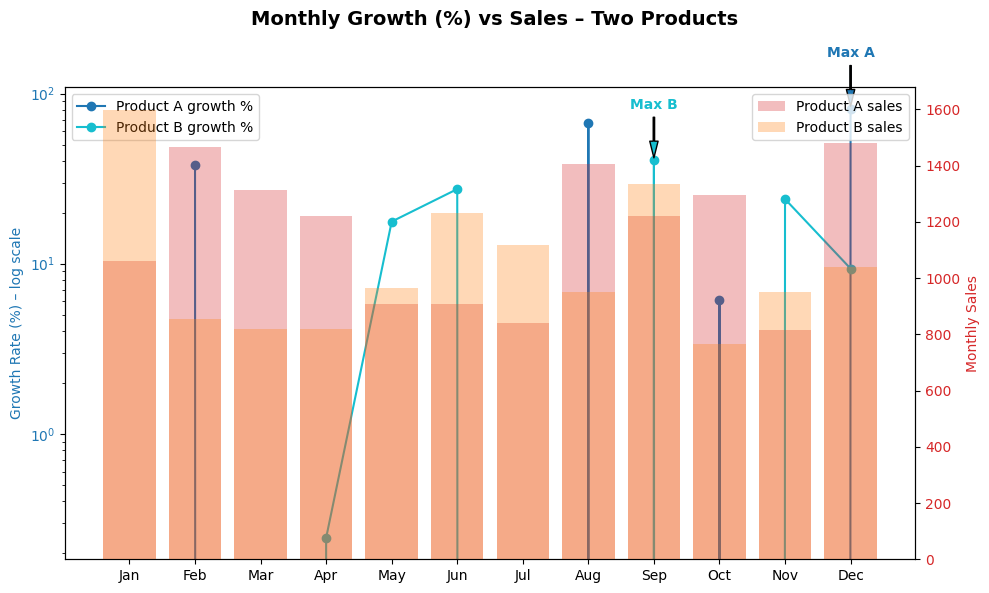

In [10]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_ylabel("Growth Rate (%) – log scale", color="tab:blue")
ax1.set_yscale("log")
line1, = ax1.plot(df["Month"], df["Growth_A(%)"], color="tab:blue",
                  marker="o", label="Product A growth %")
line2, = ax1.plot(df["Month"], df["Growth_B(%)"], color="tab:cyan",
                  marker="o", label="Product B growth %")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.set_ylabel("Monthly Sales", color="tab:red")
bar1 = ax2.bar(df["Month"], df["Sales_A"], alpha=0.3,
               color="tab:red", label="Product A sales")
bar2 = ax2.bar(df["Month"], df["Sales_B"], alpha=0.3,
               color="tab:orange", label="Product B sales", bottom=0)
ax2.tick_params(axis="y", labelcolor="tab:red")

key_A = int(np.nanargmax(df["Growth_A(%)"].values))
key_B = int(np.nanargmax(df["Growth_B(%)"].values))

def annotate_key(ax, x, y, label, color):
    ax.annotate(label,
                xy=(x, y),
                xytext=(x, y*2 if y>0 else y/2),
                arrowprops=dict(facecolor=color, shrink=0.05, width=1, headwidth=6),
                ha="center", color=color, fontsize=10, fontweight="bold")

annotate_key(ax1, df["Month"][key_A], df["Growth_A(%)"][key_A],
             "Max A", "tab:blue")
annotate_key(ax1, df["Month"][key_B], df["Growth_B(%)"][key_B],
             "Max B", "tab:cyan")

fig.suptitle("Monthly Growth (%) vs Sales – Two Products", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

fig.tight_layout()
plt.show()

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, timedelta

year = 2025

start = date(year, 1, 1)
end   = date(year, 12, 31)
dates = pd.date_range(start, end, freq="D")

np.random.seed(42)
base_activity = np.random.poisson(lam=5, size=len(dates))
for _ in range(20):
    idx = np.random.randint(0, len(dates))
    base_activity[idx] *= np.random.randint(4, 8)  
for _ in range(15):
    idx = np.random.randint(0, len(dates))
    base_activity[idx] = 0                        

df = pd.DataFrame({"date": dates, "activity": base_activity})
df["dow"] = df["date"].dt.weekday   # 0=Mon … 6=Sun
df["week"] = df["date"].apply(lambda d: d.strftime("%U")).astype(int)

q_low, q_high = df["activity"].quantile([0.05, 0.95])
df["anomaly"] = np.where(df["activity"] <= q_low, "low",
                  np.where(df["activity"] >= q_high, "high", "normal"))

df.head()

,date,activity,dow,week,anomaly
0,2025-01-01,5,2,0,normal
1,2025-01-02,4,3,0,normal
2,2025-01-03,4,4,0,normal
3,2025-01-04,5,5,0,normal
4,2025-01-05,5,6,1,normal


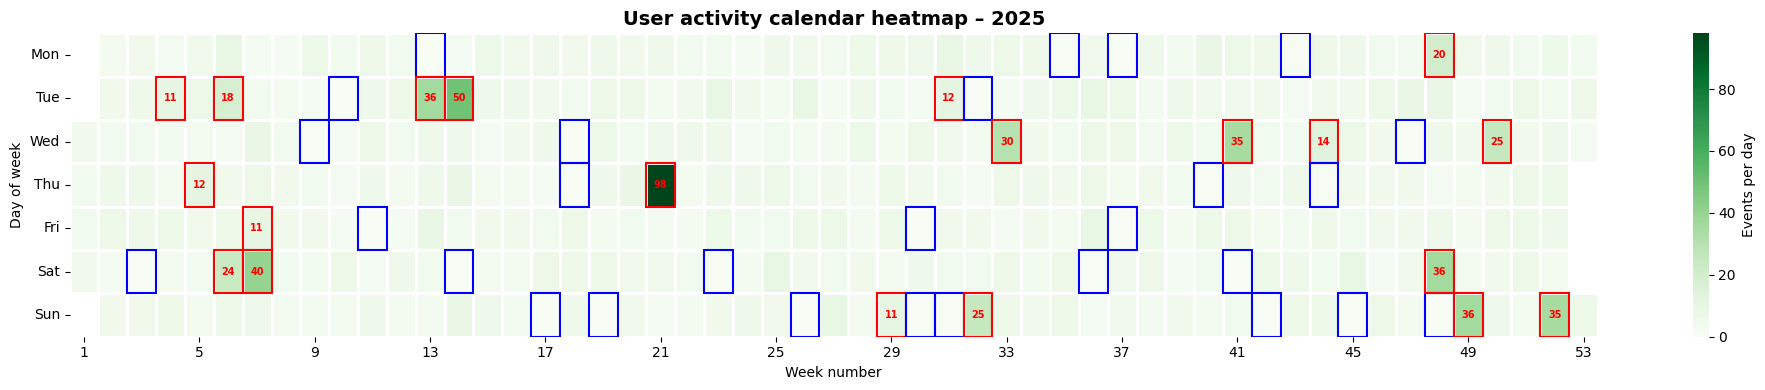

In [6]:
activity_matrix = np.zeros((7, df["week"].max() + 1)) * np.nan
anomaly_points  = []

for _, row in df.iterrows():
    w = row["week"]
    d = row["dow"]
    activity_matrix[d, w] = row["activity"]
    if row["anomaly"] != "normal":
        anomaly_points.append((w, d, row["anomaly"], row["date"], row["activity"]))

fig, ax = plt.subplots(figsize=(20, 4))
sns.heatmap(activity_matrix,
            cmap="Greens",
            linewidths=1, linecolor="white",
            cbar_kws={"label": "Events per day"},
            ax=ax)

ax.set_yticks(np.arange(7) + 0.5)
ax.set_yticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], rotation=0)
ax.set_xticks(np.arange(0.5, df["week"].max() + 1, 4))
ax.set_xticklabels(range(1, df["week"].max() + 2, 4))
ax.set_xlabel("Week number")
ax.set_ylabel("Day of week")
ax.set_title(f"User activity calendar heatmap – {year}", fontsize=14, fontweight="bold")

for w, d, kind, day, val in anomaly_points:
    color = "red" if kind == "high" else "blue"
    ax.add_patch(plt.Rectangle((w, d), 1, 1, fill=False,
                               edgecolor=color, linewidth=1.5))
    if kind == "high":
        ax.text(w + 0.5, d + 0.5, f"{val}",
                color=color, ha="center", va="center", fontsize=7, fontweight="bold")

plt.tight_layout()
plt.show()